In [91]:
# --- notebook setup ---
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

DB_PATH = "../data/training.sqlite"
conn = sqlite3.connect(DB_PATH)

print("Connected to:", DB_PATH)


Connected to: ../data/training.sqlite


In [92]:
pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)

,name
0,alerts
1,forecast_bands
2,sets
3,sqlite_sequence
4,weekly_e1rm


In [93]:
# Cell A - Load needed tables

weekly = pd.read_sql_query(
    "SELECT week_start, exercise, e1rm FROM weekly_e1rm ORDER BY week_start, exercise;", conn
)

bands = pd.read_sql_query(
    "SELECT week_start, exercise, scenario, p5, p10, p50, p90, p95 FROM forecast_bands ORDER BY week_start, exercise, scenario;", conn      
)

weekly["week_start"] = pd.to_datetime(weekly["week_start"])
bands["week_start"] = pd.to_datetime(bands["week_start"])

weekly.head(), bands.head()

(  week_start     exercise        e1rm
 0 2026-02-02  Bench Press  116.666667
 1 2026-02-02     Deadlift  204.166667
 2 2026-02-02        Squat  160.416667
 3 2026-02-09  Bench Press  115.500000
 4 2026-02-09     Deadlift  203.500000,
   week_start     exercise scenario          p5         p10         p50  \
 0 2026-03-09  Bench Press     100%  120.166667  120.166667  120.166667   
 1 2026-03-09  Bench Press      50%  120.166667  120.166667  120.166667   
 2 2026-03-09  Bench Press      75%  120.166667  120.166667  120.166667   
 3 2026-03-09     Deadlift     100%  145.833333  145.833333  145.833333   
 4 2026-03-09     Deadlift      50%  145.833333  145.833333  145.833333   
 
           p90         p95  
 0  120.166667  120.166667  
 1  120.166667  120.166667  
 2  120.166667  120.166667  
 3  145.833333  145.833333  
 4  145.833333  145.833333  )

In [94]:
# Forecast Logic check

bands[(bands["exercise"]=="Bench Press") & (bands["week_start"]>"2026-03-02")].head(9) 


,week_start,exercise,scenario,p5,p10,p50,p90,p95
0,2026-03-09,Bench Press,100%,120.166667,120.166667,120.166667,120.166667,120.166667
1,2026-03-09,Bench Press,50%,120.166667,120.166667,120.166667,120.166667,120.166667
2,2026-03-09,Bench Press,75%,120.166667,120.166667,120.166667,120.166667,120.166667
9,2026-03-16,Bench Press,100%,117.927416,118.542356,120.733344,122.991417,123.606822
10,2026-03-16,Bench Press,50%,117.678717,118.293657,120.484645,122.742718,123.358123
11,2026-03-16,Bench Press,75%,117.803067,118.418007,120.608995,122.867067,123.482473
18,2026-03-23,Bench Press,100%,117.480721,118.298166,120.958603,123.688709,124.628330
19,2026-03-23,Bench Press,50%,117.118242,117.935687,120.596124,123.326230,124.265851
20,2026-03-23,Bench Press,75%,117.299482,118.116926,120.777364,123.507470,124.447091


In [95]:
# Ordering logic check:

bench = bands[bands["exercise"]=="Bench Press"].pivot_table(
    index="week_start", columns="scenario", values="p50"
).sort_index()

bench.head(6)

scenario,100%,50%,75%
week_start,,,
2026-03-09,120.166667,120.166667,120.166667
2026-03-16,120.733344,120.484645,120.608995
2026-03-23,120.958603,120.596124,120.777364
2026-03-30,121.195038,120.723986,120.959512
2026-04-06,121.345260,120.769950,121.057605
2026-04-13,121.556455,120.880537,121.218496


In [96]:
squat = bands[bands["exercise"]=="Squat"].pivot_table(
    index="week_start", columns="scenario", values="p50"
).sort_index()

squat.head(6)

scenario,100%,50%,75%
week_start,,,
2026-03-09,181.133333,181.133333,181.133333
2026-03-16,181.994896,181.621847,181.808372
2026-03-23,182.332402,181.788683,182.060542
2026-03-30,182.690269,181.983690,182.336979
2026-04-06,182.905886,182.042920,182.474403
2026-04-13,183.224342,182.210465,182.717403


In [97]:
bands[bands.exercise=="Bench Press"].pivot(
    index="week_start", columns="scenario", values="p50"
).round(2)

scenario,100%,50%,75%
week_start,,,
2026-03-09,120.17,120.17,120.17
2026-03-16,120.73,120.48,120.61
2026-03-23,120.96,120.60,120.78
2026-03-30,121.20,120.72,120.96
2026-04-06,121.35,120.77,121.06
2026-04-13,121.56,120.88,121.22
2026-04-20,121.75,120.98,121.37
2026-04-27,121.94,121.08,121.51
2026-05-04,122.10,121.14,121.62


In [98]:
wk = weekly.copy()

wk = wk.sort_values(["exercise", "week_start"])
wk["diff"] = wk.groupby("exercise")["e1rm"].diff()
wk

,week_start,exercise,e1rm,diff
0,2026-02-02,Bench Press,116.666667,NaN
3,2026-02-09,Bench Press,115.500000,-1.166667
6,2026-02-16,Bench Press,123.750000,8.250000
9,2026-02-23,Bench Press,81.666667,-42.083333
12,2026-03-02,Bench Press,120.166667,38.500000
1,2026-02-02,Deadlift,204.166667,NaN
4,2026-02-09,Deadlift,203.500000,-0.666667
7,2026-02-16,Deadlift,217.800000,14.300000
10,2026-02-23,Deadlift,145.833333,-71.966667
2,2026-02-02,Squat,160.416667,NaN


In [99]:
# Cell B: Plots

def plot_lift(exercise: str, scenario: str = "75%"):
    w = weekly[weekly["exercise"] == exercise].sort_values("week_start")
    b = bands[(bands["exercise"] == exercise) & (bands["scenario"] == scenario)].sort_values("week_start")
    
    if w.empty:
        print(f"No weekly data for {exercise}")
        return

    if b.empty:
        print(f"No forecast data for {exercise} / {scenario}")
        return

    plt.figure()
    plt.plot(w["week_start"], w["e1rm"], marker="o", label="Actual weekly e1rm")
    plt.plot(b["week_start"], b["p50"], label=f"Forecast {scenario}")
    plt.fill_between(b["week_start"], b["p10"], b["p90"], alpha=0.2, label=f"Forecast {scenario} 10-90% band")
    
    plt.title(f"{exercise}: Actual vs Forecast ({scenario})")
    plt.xlabel("Week start")
    plt.ylabel("e1RM (kg)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

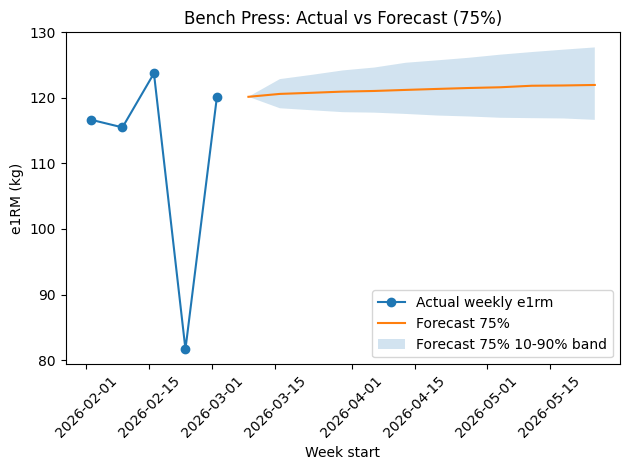

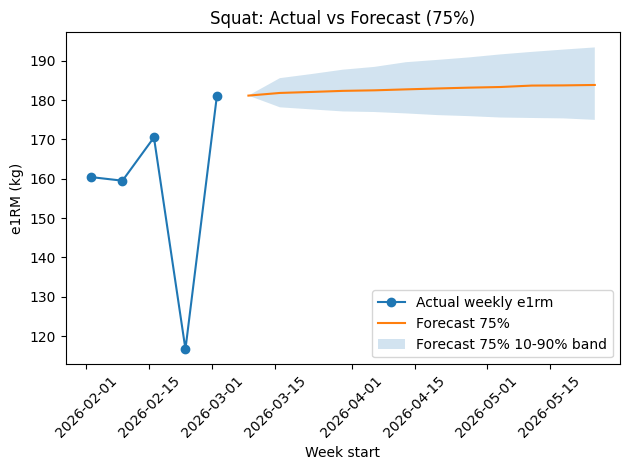

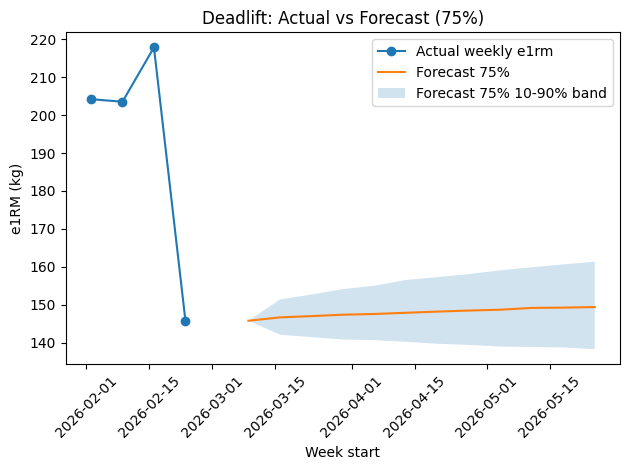

In [100]:
# Run for all lifts

for lift in ["Bench Press", "Squat", "Deadlift"]:
    plot_lift(lift, scenario="75%")